In [2]:
x1 = [
    0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 
    5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0,
    11.0, 12.0, 13.0, 14.0, 15.0
]
y = [
    41, 44, 42, 51, 48, 55, 60, 58, 64, 69, 
    71, 70, 78, 81, 84, 80, 88, 92, 90, 95,
    96, 98, 99, 97, 100
]

In [3]:
totallen = len(x1)
trainlen = (totallen/10)*8
print(totallen,trainlen)

25 20.0


In [4]:
import random

# Create list of indices and shuffle them
indices = list(range(len(x1)))
random.shuffle(indices)

train_x = []
train_y = []
test_x = []
test_y = []

# Select 80% from shuffled indices for training
for i in range(0, int(trainlen)):
    idx = indices[i]
    train_x.append(x1[idx])
    train_y.append(y[idx])

# Select remaining 20% for testing
for i in range(int(trainlen), len(x1)):
    idx = indices[i]
    test_x.append(x1[idx])
    test_y.append(y[idx])

print(train_x)
print(train_y)
print(test_x)
print(test_y)

[10.0, 5.0, 3.5, 2.5, 5.5, 14.0, 7.5, 3.0, 9.5, 8.5, 4.5, 9.0, 4.0, 2.0, 11.0, 1.5, 6.5, 13.0, 8.0, 15.0]
[95, 69, 60, 48, 71, 97, 84, 55, 90, 88, 64, 92, 58, 51, 96, 42, 78, 99, 80, 100]
[7.0, 0.5, 1.0, 6.0, 12.0]
[81, 41, 44, 70, 98]


In [5]:
def findslope(x,y):
    xmean = sum(x)/len(x)
    ymean = sum(y)/len(y)
    print(xmean)
    print(ymean)
    num = 0.0
    den = 0.0
    for i in range (0,len(x)):
        num = num + ((x[i]-xmean)*(y[i]-ymean))
        den = den + (x[i]-xmean)**2
    return num/den

m1 = findslope(train_x,train_y)
print(m1)

7.175
75.85
4.4461237055695495


In [6]:
x1mean = sum(x1)/len(x1)
ymean = sum(y)/len(y)

c = ymean - (m1*x1mean)

In [7]:
def func(x):
    y = []
    for i in range (0,len(x)):
        y.append((m1*x[i])+c)
    return y
y_train_pred = func(train_x)
y_test_pred = func(test_x)
print(y_train_pred)
print(y_test_pred)

[88.26759585782256, 66.03697732997482, 59.367791771620496, 54.92166806605094, 68.2600391827596, 106.05209068010078, 77.1522865938987, 57.14472991883572, 86.04453400503779, 81.59841029946824, 63.813915477190044, 83.82147215225302, 61.59085362440527, 52.698606213266174, 92.71371956339212, 50.47554436048139, 72.70616288832915, 101.60596697453121, 79.37534844668346, 110.49821438567031]
[74.92922474111393, 46.029420654911846, 48.25248250769662, 70.48310103554437, 97.15984326896167]


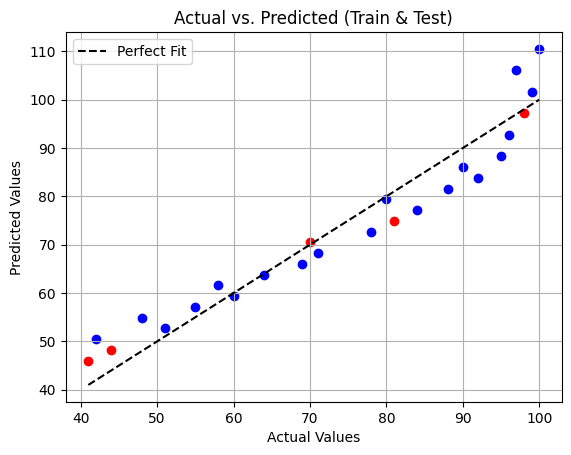

In [8]:
import matplotlib.pyplot as plt
plt.scatter(train_y,y_train_pred,color="blue")
plt.scatter(test_y,y_test_pred,color="red")
max_val = max(max(train_y), max(test_y))
min_val = min(min(train_y), min(test_y))
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', label='Perfect Fit')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted (Train & Test)')
plt.legend()
plt.grid(True)
plt.show()

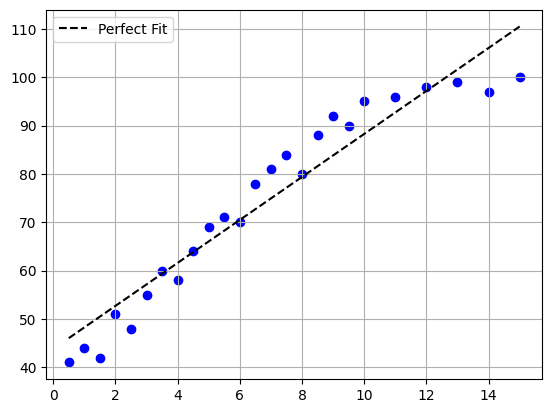

In [9]:
import matplotlib.pyplot as plt
plt.scatter(x1,y,color="blue")
plt.plot(x1,func(x1), color='black', linestyle='--', label='Perfect Fit')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
import numpy as np
x = np.array([[4,1,3],[9,2,1],[8,3,2],[8,1,1],[7,1,4],[5,0,2]])
y = np.array([52,51,50,52,70,60])
z = np.array([1,1,1])
x = np.c_[np.ones((x.shape[0], 1)), x]
print(x)
print(y)

[[1. 4. 1. 3.]
 [1. 9. 2. 1.]
 [1. 8. 3. 2.]
 [1. 8. 1. 1.]
 [1. 7. 1. 4.]
 [1. 5. 0. 2.]]
[52 51 50 52 70 60]


In [11]:
x_ = x.T.dot(x)
x_inv = np.linalg.inv(x_)
beta = x_inv.dot(x.T.dot(y))
print(beta)

[28.70422535  3.12676056 -6.          6.35211268]


In [12]:
test = np.array([1,6,1,1])
pred = test.dot(beta)
print(pred)

47.81690140845075
